# Applied Machine Learning

## Assignment5 - ShunFai Lee

In [65]:
#import all needed libraries
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_score,GridSearchCV,cross_validate
from sklearn.metrics import confusion_matrix, make_scorer, recall_score, precision_score, accuracy_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
from io import StringIO
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn import tree, neural_network
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline, Pipeline

In [5]:
# Define some common functions
def tpr_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tp / (tp + fn)

def fpr_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp / (fp + tn)

def all_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {'tpr':tp / (tp + fn),
            'fpr':fp / (fp + tn),
            'precision':tp / (fp + tp),
            'accu':(tp+tn)/(tp+tn+fp+fn),
            'f1':(2*tp)/(2*tp+fp+fn)}

scoring_metrics = {
    'accuracy': 'accuracy',
    "tpr": make_scorer(tpr_score),
    "fpr": make_scorer(fpr_score),
    "precision": make_scorer(precision_score, zero_division=0)
}

In [6]:
# function to drop duplicate rows
def drop_dup(df:pd.DataFrame):
    df["is_duplicate"]= df.duplicated()
    index_to_drop = df[df['is_duplicate']==True].index
    if len(index_to_drop)==0:
        df.drop(columns='is_duplicate', inplace=True)
    else:
        df.drop(index_to_drop, inplace=True)
        df.drop(columns='is_duplicate', inplace=True)

#function to drop rows with less than half of features available
def drop_tooManyNA(df:pd.DataFrame):
    df.dropna(thresh=len(df.columns)//2,inplace=True)



#### Preprocessing of dataset

In [36]:
#load data set
df_train = pd.read_csv("heart_dataset.csv")

print(df_train.dtypes)
# Sanity check
print(f'N={len(df_train)}, M={len(df_train.columns)}')
df_train['duplicate']=df_train.duplicated()
print(f'Number of duplicate: {len(df_train[df_train['duplicate']==True])}')
df_train=df_train.drop(columns=['duplicate'])
for x in df_train.columns:
    print(f'number of null values at column {x}: {len(df_train[df_train[x].isnull()==True])}')
df_train.head()



Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object
N=918, M=12
Number of duplicate: 0
number of null values at column Age: 0
number of null values at column Sex: 0
number of null values at column ChestPainType: 0
number of null values at column RestingBP: 0
number of null values at column Cholesterol: 0
number of null values at column FastingBS: 0
number of null values at column RestingECG: 0
number of null values at column MaxHR: 0
number of null values at column ExerciseAngina: 0
number of null values at column Oldpeak: 0
number of null values at column ST_Slope: 0
number of null values at column HeartDisease: 0


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


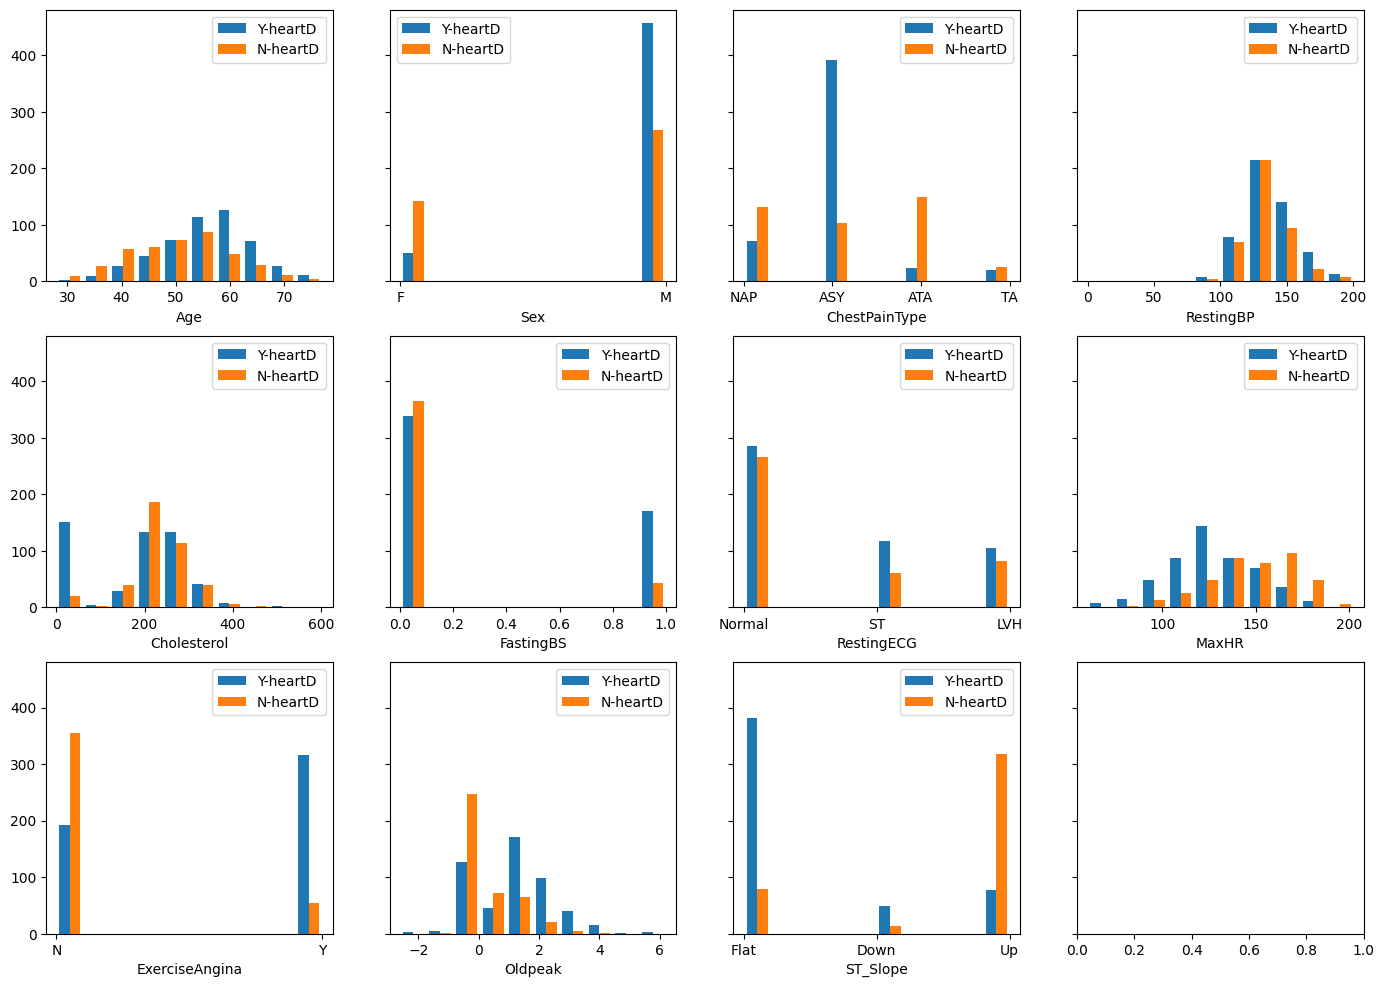

In [ ]:
def plt_var(df, class_label, _ax, _col):
    _ax.hist([df[df[class_label]==1][_col],df[df[class_label]==0][_col]], label=['Y-heartD','N-heartD'])
    _ax.set_xlabel(_col)
    _ax.legend()    


def plot_feature_hist(df,col_start, col_end):
    #4 plot in a row max
    plot_per_row = 4
    #extract feature label
    columns = df_train.columns[col_start:col_end+1]
    #extract the class label
    classlabel = df_train.columns[-1]
    #calculate number of cols needed
    cols = min(len(columns),plot_per_row)
    rows = (len(columns)+1)//plot_per_row
    _, axs = plt.subplots(nrows=rows, ncols=cols, figsize=(17, plot_per_row*rows), sharey=True)
    for i in range(len(columns)):
        x = i%plot_per_row
        y = i//plot_per_row
        plt_var(df_train, classlabel ,axs[y,x], columns[i])
    plt.show()
    
#plot histogram of all features to examine outliners
plot_feature_hist(df_train,0,-2)

In [97]:
#drop entry with more than half NA values
drop_tooManyNA(df_train)
#drop duplicates
drop_dup(df_train)

#separate class and data
df_train_X = df_train.drop(columns="HeartDisease")
df_train_Y = df_train["HeartDisease"]

# Sanity check
print(f'N={len(df_train_X)}, M={len(df_train_X.columns)}')

#define the columns that need some handling by types
numeric_cols = ['Age','RestingBP','Cholesterol','MaxHR']
categorical_cols = ['Sex','ChestPainType','RestingECG','ExerciseAngina','ST_Slope']

#set up the pipelines for different columns, with differnt impute methods and standardization/one hot encode
numeric_transform = Pipeline([('imputer',SimpleImputer(strategy='mean')),('scaler',StandardScaler())])
cat_transform = Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('encoder',OneHotEncoder(categories='auto', drop='first'))])
other_transform = Pipeline([('imputer',SimpleImputer(strategy='most_frequent'))])

#set up the transformer
preprocessor = ColumnTransformer(transformers=[('numeric',numeric_transform,numeric_cols),('categorical',cat_transform,categorical_cols)],remainder=other_transform,verbose_feature_names_out=False)

#split train and test fold
X_train, X_test, Y_train, Y_test = train_test_split(df_train_X, df_train_Y, test_size=0.1, random_state=0, stratify=df_train_Y)

#fit transform training fold and transform test fold
#X_train_encoded = preprocessor.fit_transform(X_train)
X_train_encoded = pd.DataFrame(data=preprocessor.fit_transform(X_train),columns=preprocessor.get_feature_names_out())
X_test_encoded = pd.DataFrame(data=preprocessor.transform(X_test),columns=preprocessor.get_feature_names_out())

df_train_encoded = pd.DataFrame(data=preprocessor.fit_transform(df_train_X),columns=preprocessor.get_feature_names_out())


N=918, M=11


In [98]:
# 10-fold CV evaluation of a classifier on a pipeline
def eval_classifier_pipeline(pipeline, _X, _y):
    accuracies = []
    kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
    for train_index, test_index in kf.split(_X, _y):
        pipeline.fit(_X.iloc[train_index], _y.iloc[train_index])
        y_pred = pipeline.predict(_X.iloc[test_index])
        accuracies += [accuracy_score(_y.iloc[test_index], y_pred)]
    return np.array(accuracies)

#calculate the CV performance on the whole data set with transform pipeline
_clf = [GaussianNB(),SVC(kernel='linear',probability=True),neural_network.MLPClassifier(),tree.DecisionTreeClassifier()]
CV_result = {}
for c in _clf:
    pipe_lr = make_pipeline(preprocessor,c)
    result = eval_classifier_pipeline(pipe_lr,df_train_X,df_train_Y)
    CV_result.update({c.__class__.__name__:[result.mean(),result.std()]})
for r in CV_result:
    print(f'{r}:accuracy:{CV_result[r][0]:.2f}{chr(177)}{CV_result[r][1]:.2f}')

#use the encoded train test splited set for randomforestclassifier
forest = RandomForestClassifier()
forest.fit(X_train_encoded,Y_train)
Y_pred_forest =forest.predict(X_test_encoded)
print(f'Random forest:accuracy:{accuracy_score(Y_test,Y_pred_forest):.2f}')


g:\phoenixDocuments\GitHub\MachineLearning\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
g:\phoenixDocuments\GitHub\MachineLearning\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
g:\phoenixDocuments\GitHub\MachineLearning\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
g:\phoenixDocuments\GitHub\MachineLearning\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converge

GaussianNB:accuracy:0.86±0.04
SVC:accuracy:0.86±0.03
MLPClassifier:accuracy:0.87±0.03
DecisionTreeClassifier:accuracy:0.79±0.04
Random forest:accuracy:0.84


g:\phoenixDocuments\GitHub\MachineLearning\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


### Question1:

####  10-fold cross-validation performances of GaussianNB, SVC, MLPClassifier and DecisionTreeClassifier, and performance of RandomForestClassifier 
The performance of GaussianNB, SVC, MLPClassifier and DecisionTreeClassifier with default setting, by using 10 fold cross validation, as well as the standalone RandomForestClassifier are summarized as follows:
|Model|Accuracy Score|
|---|---|
|GaussianNB|0.86±0.04|
|SVC|0.86±0.03|
|MLPClassifier|0.87±0.04|
|DecisionTreeClassifier|0.79±0.04|
|Random Forest|0.86|

It is also worth to note that there are warnings on convergence of the MLPClassifier and random forest classifier, which indicates that the hyperparameters might not be ideal and that performance are not optimal.

### Question2:

#### ensemble of 100 classifiers of GaussianNB, SVC, MLPClassifier and DecisionTreeClassifier with bagging method

In [100]:
# 10-fold CV evaluation of a classifier
def eval_classifier(clf, _X, _y):
    accuracies = []
    kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
    for train_index, test_index in kf.split(_X, _y):
        clf.fit(_X.iloc[train_index], _y.iloc[train_index])
        y_pred = clf.predict(_X.iloc[test_index])
        accuracies += [accuracy_score(_y.iloc[test_index], y_pred)]
    return np.array(accuracies)

#ensemble size
ensemble_size = 100
GNB = [GaussianNB() for _ in range(ensemble_size)]
SVClinear = [SVC(kernel='linear',probability=True) for _ in range(ensemble_size)]
MLP=[neural_network.MLPClassifier(hidden_layer_sizes=(3,3),max_iter=30,tol=1e-1) for _ in range(ensemble_size)]
Dtree=[tree.DecisionTreeClassifier(max_depth=5,max_features=5) for _ in range(ensemble_size)]

#find the 1st classifier's performance
clf_1 = [GNB[0],SVClinear[0],MLP[0],Dtree[0]]
Result_1st_clf = {}
for c in clf_1:
    result = eval_classifier(c,df_train_encoded,df_train_Y)
    Result_1st_clf.update({c.__class__.__name__:[result.mean(),result.std()]})
for r in Result_1st_clf:
    print(f'{r}:accuracy:{Result_1st_clf[r][0]:.2f}{chr(177)}{Result_1st_clf[r][1]:.2f}')

GaussianNB:accuracy:0.86±0.04
SVC:accuracy:0.86±0.03
MLPClassifier:accuracy:0.55±0.06
DecisionTreeClassifier:accuracy:0.83±0.03


### Question2:

For the 4 ensembles, the performance of the 1st weak sub-classifiers are summarized as follows:
|Model|Accuracy Score|
|---|---|
|GaussianNB|0.86±0.04|
|SVC|0.86±0.03|
|MLPClassifier|0.56±0.08|
|DecisionTreeClassifier|0.83±0.05|

Because GaussianNB and SVC are essentially the same as question 1, so their performance are the same. But because the hyperparameter of neural network and decision tree are restricted, the neural network showed a very clear drop in performance, while the decision tree showed very similar performance, but with higher variance.

### Question3: 

####  ensemble_fit() for the bagging method

In [116]:
import random
#function to fit each weak classifier in the ensemble
def ensemble_fit(ensemble_list:list, X, Y, sample_ratio):
    #iterate through each sub classifier
    totalsize = len(X)
    sample_size = int(totalsize*sample_ratio)
    for i in range(len(ensemble_list)):
        #random.sample does not allow replacement
        #so use np.random.choice instead to get a subsample index list
        samples = np.random.choice(totalsize,size=sample_size,replace=True)
        #get the sub samples
        X_sub = X.iloc[samples]
        Y_sub = Y.iloc[samples]
        #fit the sub-classifier
        ensemble_list[i].fit(X_sub,Y_sub)
    return ensemble_list

#GNB = ensemble_fit(GNB,X_train_encoded,Y_train)
#SVClinear = ensemble_fit(SVClinear,X_train_encoded,Y_train)
#MLP = ensemble_fit(MLP,X_train_encoded,Y_train)
#Dtree = ensemble_fit(Dtree,X_train_encoded,Y_train)


### Question4: 

####  ensemble_predict() to receive the trained ensemble and output a prediction for a given observation

In [127]:
# Using trained ensemble, predict the outcome by majority voting with summing probability
def ensemble_predict(ensemble_list, x_input):
    
    # probability of different class of each weak learner
    
    y_prob = np.array([m.predict_proba(x_input) for m in ensemble_list])
    
    #y_prob = []
    #for i in range(len(ensemble_list)):
    #    result_prop = ensemble_list[i].predict_proba(x_input)
    #    
    #    y_prob.append(result_prop)
    # sum up probability, assume equal weighting for each class and each classfier
    sum_prop = np.sum(y_prob,axis=0)
    # use argmax to find the winning classes
    winning_index = np.argmax(sum_prop,axis=1)
    actual_class_label = ensemble_list[0].classes_[winning_index]

    return actual_class_label

GNB = ensemble_fit(GNB,X_train_encoded,Y_train,0.2)
y_predict = ensemble_predict(GNB,X_test_encoded)
score = accuracy_score(Y_test,y_predict)
score

0.8369565217391305

### Question5: 

####  10-fold CV performances of the ensembles with a subsample ratio of 0.2
####  Compare to a regular decision tree